In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re
from typing import List, Tuple

In [64]:
data_path = '../../Data/InputData'
data_files = [os.path.join(data_path,x) for x in os.listdir(data_path) if x.endswith('.csv')] 

# Load data
faulty_zip_1 = pd.read_csv(data_files[0], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
faulty_zip_2 = pd.read_csv(data_files[1], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
faulty_1 = pd.read_csv(data_files[2], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
faulty_2 = pd.read_csv(data_files[3], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
healhty_zip_1 = pd.read_csv(data_files[4], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
healhty_zip_2 = pd.read_csv(data_files[5], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
healhty_1 = pd.read_csv(data_files[6], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]
healhty_2 = pd.read_csv(data_files[7], delimiter=";", skiprows=6,index_col='Sample')[['CURRENT (V)','Time (s)','ROTO (V)']]


In [65]:
# data downsampled
data_files_down = [os.path.join(data_path,'downsampled',x) for x in os.listdir(os.path.join(data_path,'downsampled')) if x.endswith('.csv')]

faulty_zip_1_d = pd.read_csv(data_files_down[0],index_col='SampleNo')
faulty_zip_2_d = pd.read_csv(data_files_down[1],index_col='SampleNo')
faulty_1_d = pd.read_csv(data_files_down[2],index_col='SampleNo')
faulty_2_d = pd.read_csv(data_files_down[0],index_col='SampleNo')
healhty_zip_1_d = pd.read_csv(data_files_down[1],index_col='SampleNo')
healhty_zip_2_d = pd.read_csv(data_files_down[2],index_col='SampleNo')
healhty_1_d = pd.read_csv(data_files_down[0],index_col='SampleNo')
healhty_2_d = pd.read_csv(data_files_down[1],index_col='SampleNo')



In [66]:
data_files_down

['../../Data/InputData/downsampled/2025-02-28-F8_uszkodzony_2_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-F8_uszkodzony_1_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-zdrowy_trytytka_2_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-zdrowy_trytytka_1_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-F8_uszkodzony_trytytka_2_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-zdrowy_1_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-zdrowy_2_downsample_10x.csv',
 '../../Data/InputData/downsampled/2025-02-28-F8_uszkodzony_trytytka_1_downsample_10x.csv']

In [67]:
def plot_from(df,starts,stops):
    fig, ax = plt.subplots(2,1,figsize=(8,8))
    tmp = df.iloc[df[df['Time (s)'] == starts].index.values[0]:df[df['Time (s)'] == stops].index.values[0]]
    ax[0].plot(tmp['Time (s)'],tmp['CURRENT (A)'])
    ax[0].set_title('Current') 
    ax[1].plot(tmp['Time (s)'],tmp['ROTO (RPM)'])
    ax[1].set_title('Rotational speed') 
    plt.show()

def rescale_current_rotor(df):
    df.loc[:, 'CURRENT (A)'] = (df['CURRENT (V)'] - 2.5) * 20 / 2.5
    df.loc[:, 'ROTO (RPM)'] = df['ROTO (V)'] * 10000
    return df.drop(columns=['CURRENT (V)','ROTO (V)'])


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply Seaborn's whitegrid style globally
sns.set(style="whitegrid")

def plot_from(df, starts, stops):
    fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Slice the relevant data
    tmp = df.iloc[
        df[df['Time (s)'] == starts].index.values[0]:
        df[df['Time (s)'] == stops].index.values[0]
    ]

    # Plot Current
    ax[0].plot(tmp['Time (s)'], tmp['CURRENT (A)'], color='dodgerblue', linewidth=2)
    ax[0].set_title('Current Over Time', fontsize=14)
    ax[0].set_ylabel('Current (A)', fontsize=12)

    # Plot Rotor Speed
    ax[1].plot(tmp['Time (s)'], tmp['ROTO (RPM)'], color='mediumseagreen', linewidth=2)
    ax[1].set_title('Rotational Speed Over Time', fontsize=14)
    ax[1].set_xlabel('Time (s)', fontsize=12)
    ax[1].set_ylabel('Speed (RPM)', fontsize=12)

    # Improve overall layout and spacing
    plt.tight_layout()
    plt.show()


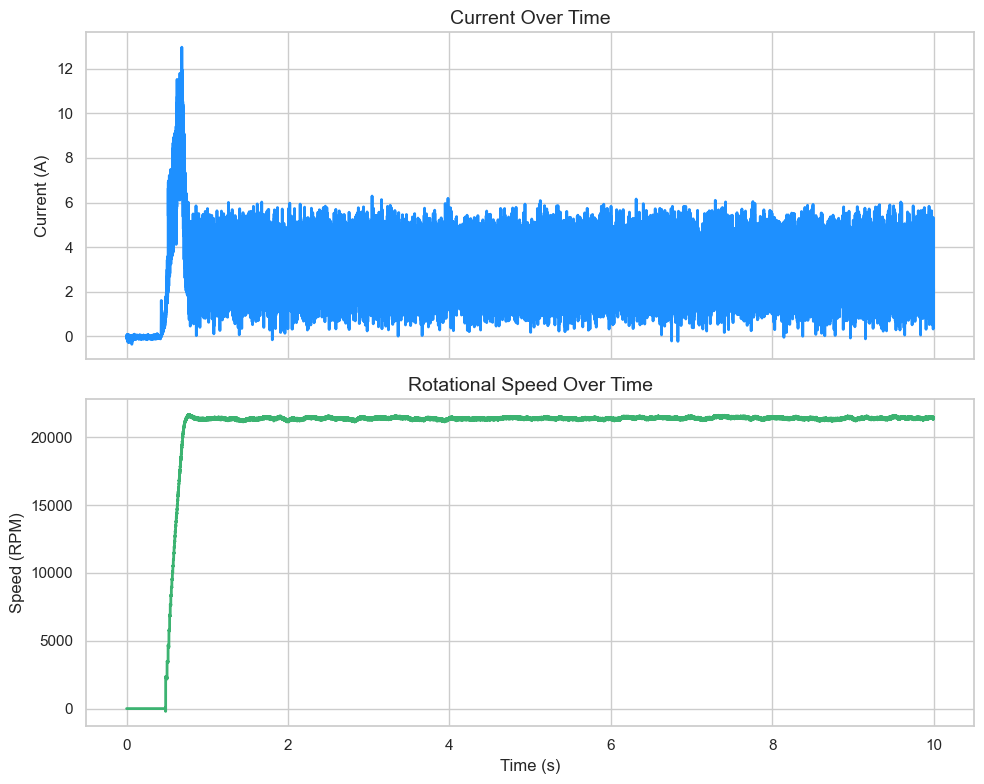

In [69]:
plot_from(rescale_current_rotor(nowy_1_down),0,1)

In [70]:
def get_samples(dfs, start_times, window_size, sampling_rate, name):
    curr_id = 0
    sampled_dfs = []
    points_per_window = int(window_size * sampling_rate)
    
    for df, time in zip(dfs, start_times):
        temp_df = rescale_current_rotor(df.copy())
        start_index = temp_df[temp_df['Time (s)'] == time].index.values[0]
        temp_df = temp_df.iloc[start_index:]
        temp_df['Time (s)'] = temp_df['Time (s)'] - time
        
        total_groups = len(temp_df) // points_per_window
        
        for group in range(total_groups):
            start_point = group * points_per_window
            end_point = start_point + points_per_window
            
            group_df = temp_df.iloc[start_point:end_point].copy()
            group_df['Experiment ID'] = curr_id + group
            group_df['Time (s)'] = group_df['Time (s)'] - group * window_size
            
            sampled_dfs.append(group_df)
        
        curr_id += total_groups
    
    dfs_concat = pd.concat(sampled_dfs, ignore_index=True)
    dfs_concat.to_csv(f'../../Data/IntermediateData/{name}.csv', index=False)
    return dfs_concat

In [71]:
# Rescale and choose window size
window_size = 0.8
cutoff = 1.6

sampling_rate = 50000
faulty_zip = get_samples([faulty_zip_1,faulty_zip_2], [cutoff,cutoff],window_size,sampling_rate, 'faulty_zip')
faulty = get_samples([faulty_1,faulty_2], [cutoff,cutoff], window_size,sampling_rate, 'faulty')
healhty_zip = get_samples([healhty_zip_1,healhty_zip_2], [cutoff,cutoff], window_size,sampling_rate, 'healhty_zip')
healhty = get_samples([healhty_1,healhty_2], [cutoff,cutoff], window_size,sampling_rate, 'healhty')

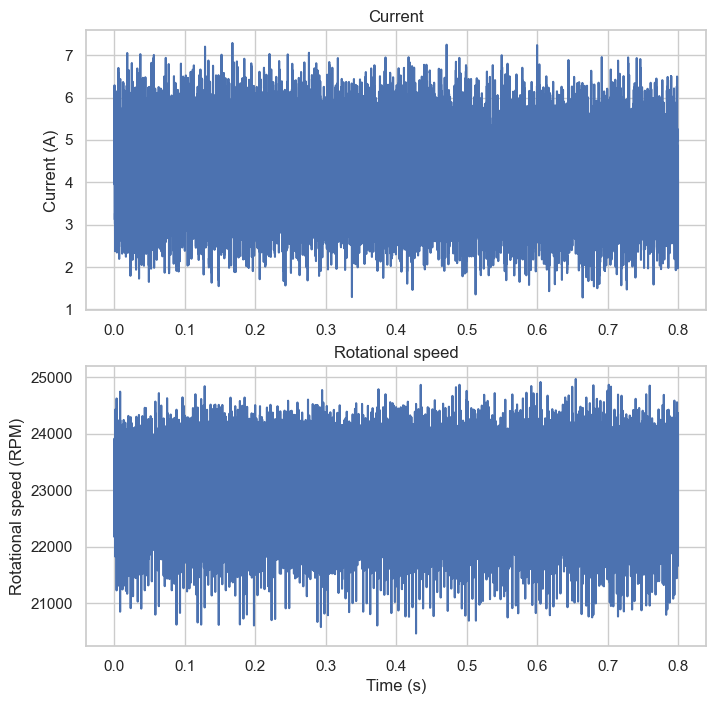

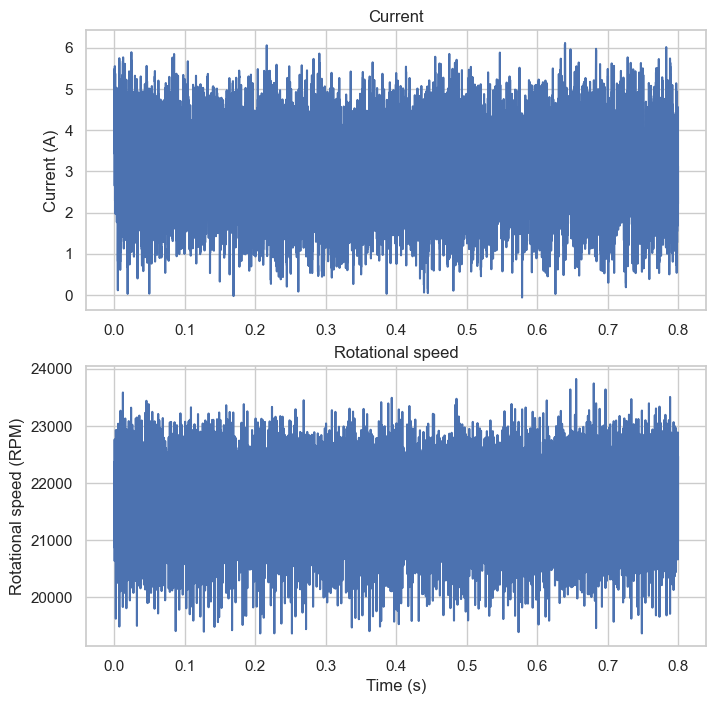

In [72]:
def plot_experiment(df, exp_id):
    fig, ax = plt.subplots(2,1,figsize=(8,8))
    tmp = df[df['Experiment ID'] == exp_id]
    ax[0].plot(tmp['Time (s)'],tmp['CURRENT (A)'])
    ax[0].set_title('Current') 
    ax[0].set_ylabel('Current (A)')
    ax[1].plot(tmp['Time (s)'],tmp['ROTO (RPM)'])
    ax[1].set_title('Rotational speed') 
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Rotational speed (RPM)')

    plt.show()

plot_experiment(faulty,4)
plot_experiment(healhty,3)

In [73]:
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd

def crest_factor(x):
    return np.max(x) / np.mean(x)

def rms(x):
    return np.sqrt(np.mean(x**2))

def peak_to_peak(x):
    return np.ptp(x)

def amplitude_spectrum(signal_data, fs=50000):
    N = len(signal_data)
    freq_axis = np.fft.fftfreq(N, 1/fs)[:N // 2]
    spectrum = np.abs(fft(signal_data))[:N // 2]
    return freq_axis, spectrum

def frequency_domain_features(signal_data, fs):
    freq_axis, spectrum = amplitude_spectrum(signal_data, fs)
    features = {}
    
    if np.sum(spectrum) == 0:
        return features
    
    features["Frequency Center"] = np.sum(freq_axis * spectrum) / np.sum(spectrum)
    features["Spectrum Area"] = np.sum(spectrum)

    rotation_speed = signal_data.mean()
    features["Amp @ 1x RPM"] = spectrum[np.argmin(np.abs(freq_axis - rotation_speed))]
    features["Amp @ 2x RPM"] = spectrum[np.argmin(np.abs(freq_axis - 2 * rotation_speed))]
    features["Amp @ 3x RPM"] = spectrum[np.argmin(np.abs(freq_axis - 3 * rotation_speed))]


    return features

def add_stats(df, fs=50000):
    df_temp = df.copy()
    
    # Time-Domain Features
    time_features = {
        'CURRENT (A)': ['mean', 'std', 'max', rms, peak_to_peak, skew, kurtosis, crest_factor],
        'ROTO (RPM)': ['mean', 'std', 'max', rms, peak_to_peak, skew, kurtosis, crest_factor]
    }
    
    df_stats = df_temp.groupby('Experiment ID').agg(time_features)
    df_stats.columns = [f'{col[0]} {col[1]}' for col in df_stats.columns]
    
    # Frequency-Domain Features
    freq_feature_list = []
    for exp_id, group in df_temp.groupby('Experiment ID'):
        current_freq_features = frequency_domain_features(group['CURRENT (A)'].values, fs)
        roto_freq_features = frequency_domain_features(group['ROTO (RPM)'].values, fs)
        
        freq_features = {f'CURRENT (A) {key}': value for key, value in current_freq_features.items()}
        freq_features.update({f'ROTO (RPM) {key}': value for key, value in roto_freq_features.items()})
        freq_feature_list.append([exp_id] + list(freq_features.values()))
    
    freq_feature_df = pd.DataFrame(freq_feature_list, columns=['Experiment ID'] + list(freq_features.keys()))
    
    df_final = df_stats.reset_index().merge(freq_feature_df, on='Experiment ID', how='left')
    return df_final


faulty_stats = add_stats(faulty)
healhty_stats = add_stats(healhty)
faulty_zip_stats = add_stats(faulty_zip)
healhty_zip_stats = add_stats(healhty_zip)

faulty_stats.set_index('Experiment ID', inplace=True)
healhty_stats.set_index('Experiment ID', inplace=True)
faulty_zip_stats.set_index('Experiment ID', inplace=True)
healhty_zip_stats.set_index('Experiment ID', inplace=True)


In [74]:
faulty_stats.head()

,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,ROTO (RPM) std,...,CURRENT (A) Frequency Center,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM
Experiment ID,,,,,,,,,,,,,,,,,,,,,
0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,518.422127,...,2864.797127,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004
1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,521.269101,...,2820.710573,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568
2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,522.826496,...,2800.085704,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909
3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,525.727297,...,2699.888592,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562
4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,522.741943,...,2796.335695,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080


In [75]:
faulty_stats.to_csv(f'../../Data/AnalysisData/faulty.csv')
healhty_stats.to_csv(f'../../Data/AnalysisData/healthy.csv')
faulty_zip_stats.to_csv(f'../../Data/AnalysisData/faulty_zip.csv')
healhty_zip_stats.to_csv(f'../../Data/AnalysisData/healthy_zip.csv')

In [76]:
faulty_stats['Class'] = 'Elec_Damage'
healhty_stats['Class'] = 'Healthy'
faulty_zip_stats['Class'] = 'Mech_Elec_Damage'
healhty_zip_stats['Class'] = 'Mech_Damage'

motors_df = pd.concat([faulty_stats, healhty_stats, faulty_zip_stats, healhty_zip_stats], ignore_index=True)

motors_df.to_csv('../../Data/AnalysisData/motors.csv')

In [77]:
motors_df.head()

,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,ROTO (RPM) std,...,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM,Class
0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,518.422127,...,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004,Elec_Damage
1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,521.269101,...,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568,Elec_Damage
2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,522.826496,...,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909,Elec_Damage
3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,525.727297,...,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562,Elec_Damage
4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,522.741943,...,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080,Elec_Damage
